# ⚡️ Baseline Forecast: Lag‑7 Day

Welcome! In this guided tutorial, we’ll build a **simple but strong baseline** for energy demand forecasting:  
**Lag‑7** (yesterday's value from **one week ago**) ➜ a solid benchmark for daily/weekly seasonal loads.

**What you'll learn:**
- 📥 Data loading & time indexing  
- 🧹 Cleaning missing data  
- 🧪 Train/validation/test splits  
- 🧰 Feature engineering (lags/rolling)  
- 🔮 Baseline: **Lag‑7** prediction  
- 📏 Metrics (MAE, RMSE, MAPE) and plots  
- ✅ How to use this as a yardstick for fancier models later

> Tip: Keep this baseline around! If a fancy model can’t beat Lag‑7, it’s probably **overkill** or mis‑specified.

## 🛠️ Setup & Imports

We import core libraries for data handling (**pandas**, **numpy**), visualization (**matplotlib/seaborn**),  
and metrics (**sklearn.metrics**). Keep it minimal and reproducible.

## 📊 Visualization & Diagnostics

Plot **actual vs predicted**, **residuals**, and **error distributions**.  
Look for **bias** (systematic under/over‑prediction) and **seasonal drift**.

In [11]:
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_percentage_error

import warnings
warnings.filterwarnings('ignore')

# Read datasets

## 📥 Load the Data

Read raw time‑series, parse **datetime**, and set a meaningful **index**.  
Ensure the frequency is clear (hourly/daily) and units are documented (e.g., **kWh**, **kW**).

## 🕒 Time Index & Frequency

Make the **DatetimeIndex** consistent, set frequency, handle timezones, and align to the desired granularity.  
This prevents subtle off‑by‑one errors later.

In [12]:
dataset = pd.read_csv('data/kaggle_competition_dataset.csv',
            parse_dates=['time'])
dataset.set_index('time', inplace=True)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8592 entries, 2021-09-01 00:00:00 to 2022-08-24 23:00:00
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temp         8592 non-null   float64
 1   dwpt         8592 non-null   float64
 2   rhum         8592 non-null   float64
 3   prcp         2159 non-null   float64
 4   snow         119 non-null    float64
 5   wdir         8592 non-null   float64
 6   wspd         8592 non-null   float64
 7   wpgt         8592 non-null   float64
 8   pres         8592 non-null   float64
 9   coco         8396 non-null   float64
 10  el_price     8592 non-null   float64
 11  consumption  8592 non-null   float64
dtypes: float64(12)
memory usage: 872.6 KB


# Features


In [13]:
demand = dataset[['consumption']]
demand = demand.rename(columns = {'consumption':'demand'})
demand.head()

,demand
time,
2021-09-01 00:00:00,0.577
2021-09-01 01:00:00,0.594
2021-09-01 02:00:00,0.685
2021-09-01 03:00:00,1.016
2021-09-01 04:00:00,0.677


## 🧰 Feature Engineering (Light)

Create interpretable signals:  
- 🔁 **Lags** (e.g., 1, 24, **7×period** for weekly seasonality)  
- 📈 **Rolling stats** (mean/std/min/max)  
- 📆 **Calendar** features (DoW, hour, holidays)

## 🔮 Baseline Model: Lag‑7

Predict **today** using the value from **7 periods ago** (e.g., 7 days for daily; 24×7 for hourly).  
This leverages **weekly seasonality**, often surprisingly strong in buildings & homes.

In [14]:
lag7d = demand[['demand']].shift(24*7)
lag7d = lag7d.rename(columns = {'demand':'lag7'})
features = lag7d.copy()
features

,lag7
time,
2021-09-01 00:00:00,NaN
2021-09-01 01:00:00,NaN
2021-09-01 02:00:00,NaN
2021-09-01 03:00:00,NaN
2021-09-01 04:00:00,NaN
...,...
2022-08-24 19:00:00,0.897
2022-08-24 20:00:00,2.796
2022-08-24 21:00:00,0.733


# Forecast

In [15]:
dataset = demand.join(features)
dataset.tail()

,demand,lag7
time,,
2022-08-24 19:00:00,0.678,0.897
2022-08-24 20:00:00,0.457,2.796
2022-08-24 21:00:00,0.500,0.733
2022-08-24 22:00:00,2.321,1.490
2022-08-24 23:00:00,0.678,0.222


In [16]:
test_set = dataset[(dataset.index >= datetime.datetime(2022,8, 1))]
test_set

,demand,lag7
time,,
2022-08-01 00:00:00,0.200,0.225
2022-08-01 01:00:00,0.253,0.201
2022-08-01 02:00:00,0.200,0.200
2022-08-01 03:00:00,0.183,0.225
2022-08-01 04:00:00,1.230,1.118
...,...,...
2022-08-24 19:00:00,0.678,0.897
2022-08-24 20:00:00,0.457,2.796
2022-08-24 21:00:00,0.500,0.733


## 📏 Evaluation Metrics

Report multiple metrics:  
- **MAE**: average absolute error (units of target)  
- **RMSE**: penalizes large errors  
- **MAPE**: % error (watch out for near‑zero issues)

Add **baseline vs model** tables and quick plots for a fair comparison.

MAPE: 69.962


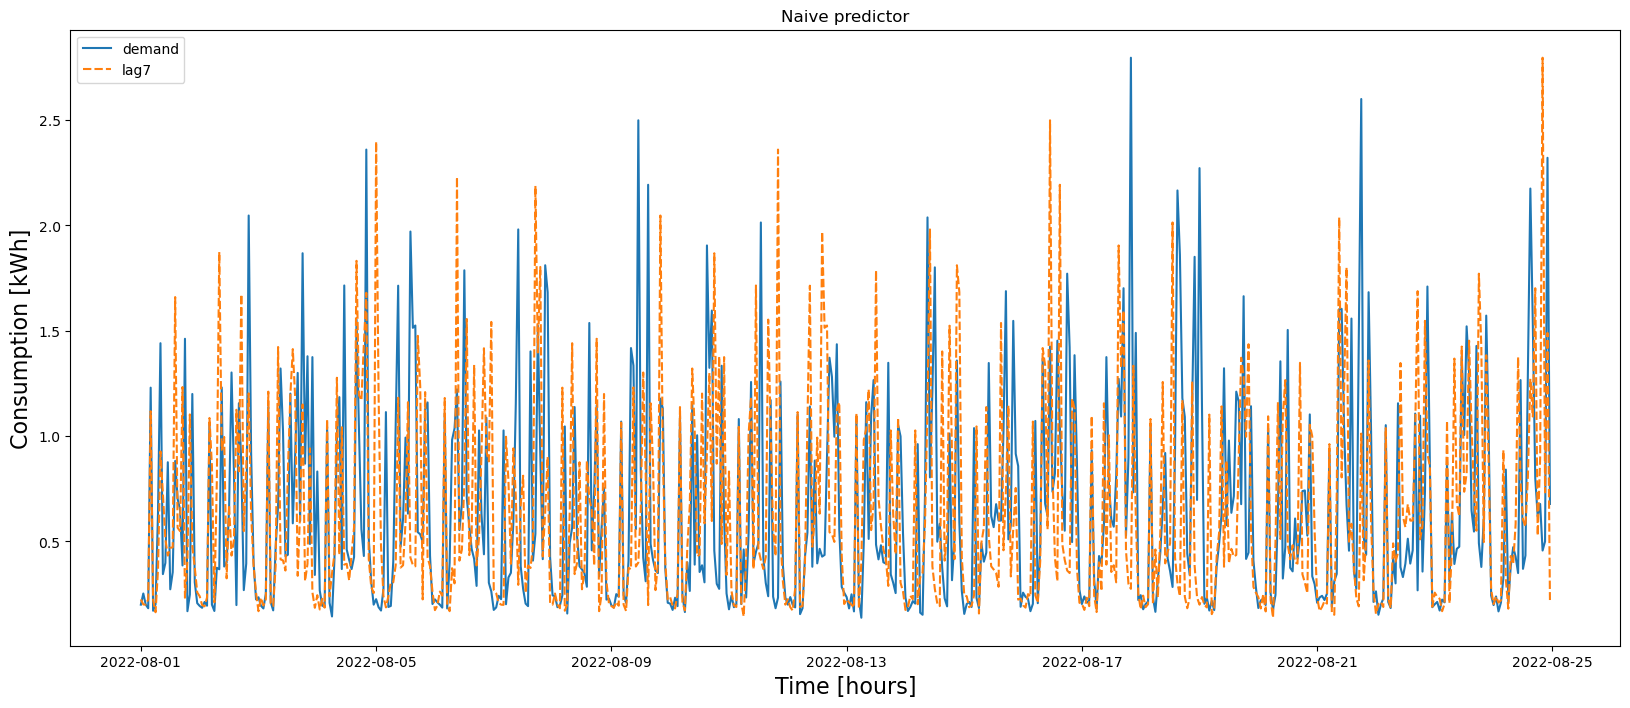

In [17]:
plt.figure(figsize=(20,8))
plt.title("Naive predictor")
p = sns.lineplot(data = test_set[['demand','lag7']]);

p.set_xlabel("Time [hours]", fontsize = 16);
p.set_ylabel("Consumption [kWh]", fontsize = 16);

print("MAPE: %.3f" % (mean_absolute_percentage_error(test_set['demand'], test_set['lag7'])*100))

MAPE: 86.357


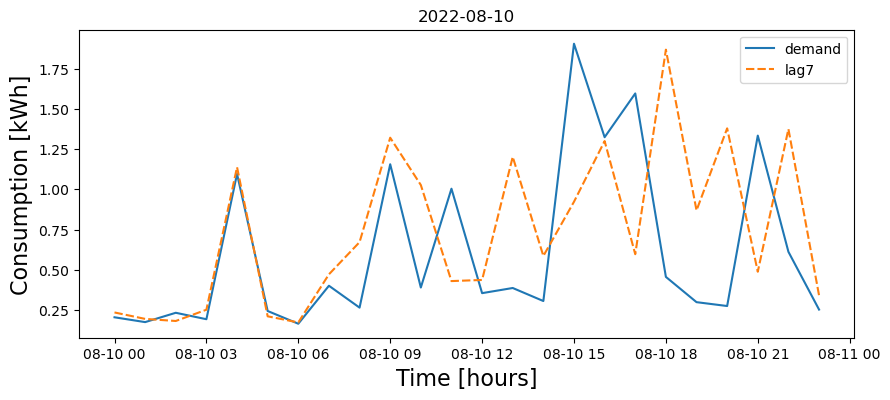

In [18]:
predict_for_start = datetime.datetime(2022,8,10)
predict_for_end = predict_for_start + datetime.timedelta(days = 1)

test_day = test_set[(test_set.index >= predict_for_start) &  (test_set.index < predict_for_end)]

plt.figure(figsize=(10,4))
plt.title(predict_for_start.date())
p = sns.lineplot(data = test_day[['demand','lag7']]);
p.set_xlabel("Time [hours]", fontsize = 16);
p.set_ylabel("Consumption [kWh]", fontsize = 16);

print("MAPE: %.3f" % (mean_absolute_percentage_error(test_day['demand'], test_day['lag7'])*100))

MAPE: 63.332


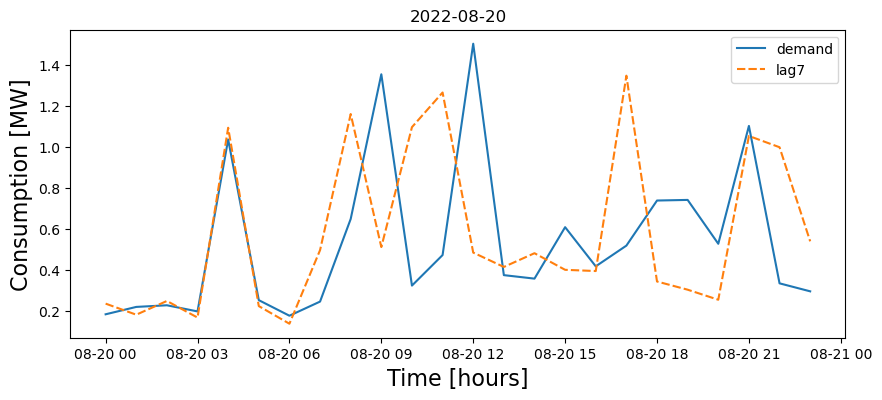

In [19]:
# holiday
predict_for_start = datetime.datetime(2022,8,20)
predict_for_end = predict_for_start + datetime.timedelta(days = 1)

test_day = test_set[(test_set.index >= predict_for_start) &  (test_set.index < predict_for_end)]

plt.figure(figsize=(10,4))
plt.title(predict_for_start.date())
p = sns.lineplot(data = test_day[['demand','lag7']]);
p.set_xlabel("Time [hours]", fontsize = 16);
p.set_ylabel("Consumption [MW]", fontsize = 16);

print("MAPE: %.3f" % (mean_absolute_percentage_error(test_day['demand'], test_day['lag7'])*100))